# Running modulation of V1 responses: binary running/still analysis (B1–B7)

This notebook quantifies how locomotion modulates V1 neural responses using a
**binary running/still classification**, separately for each stimulus type
(`drifting_gratings`, `static_gratings`, `natural_scenes`) and for
`spontaneous` activity (the no-stimulus baseline).

Reusable analysis and plotting code lives in `utils.py`
(`BinaryModulation` and the `run_binary_modulation_analysis` /
`summarize_*` / `compare_*` / `validate_*` / `plot_*` helpers). This notebook
only calls those helpers and narrates the results.

**Trial extraction notes** (handled inside `extract_trials`, not repeated here):

- Stimuli are extracted and analyzed **separately** at every step — raw
  trials are never pooled across stimulus classes.
- The drifting-gratings response window is ~60 frames (2 s); static-gratings
  and natural-scenes response windows are ~7 frames (0.23 s), reflecting
  each stimulus's own trial duration.
- The blank natural-scene frame (`frame == -1`) is excluded automatically.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    load_data,
    run_binary_modulation_analysis,
    summarize_binary_modulation_runs,
    summarize_mi_by_stimulus,
    summarize_gain_model,
    compare_gratings_vs_natural,
    validate_mi_against_metadata,
    plot_raw_mi_histograms,
    plot_robust_mi_histograms,
    plot_population_response_scatter,
    plot_condition_gain_example,
    plot_grating_natural_paired_scatter,
    plot_grating_natural_paired_distribution,
    plot_metadata_validation,
)

DENOM_THRESHOLD = 1e-3

In [2]:
data = load_data("data")

RESPONSE_WINDOWS = {
    "drifting_gratings": (10, 60),
    "static_gratings": (5, 7),
    "natural_scenes": (5, 7),
    "spontaneous": (0, 60),
}

print("Matched cells:", len(data["matched_cell_ids"]))

Matched cells: 47


In [3]:
results = run_binary_modulation_analysis(
    data,
    RESPONSE_WINDOWS,
    run_threshold=3.0,
    still_threshold=0.5,
    min_trials_per_state=2,
)

run_summary = summarize_binary_modulation_runs(results)
run_summary

,stimulus,n_trials,n_running,n_still,n_ignored,median_MI,valid_gain_fits
0,drifting_gratings,598,195,28,375,0.125199,47
1,static_gratings,5811,1825,2722,1264,0.026739,47
2,natural_scenes,5900,1315,2997,1588,0.244089,47
3,spontaneous,296,44,26,226,-0.199295,0


The sanity-check table above confirms the pipeline ran correctly for every
stimulus: expected trial counts, a non-trivial split into running/still
trials, and (except for `spontaneous`, which has no stimulus-condition
structure) valid gain fits for all 47 matched cells.

## 1. Running modulation across stimulus types

### 1.1 Running/still classification and modulation index (MI)

Each trial is classified as:

- **running** — mean speed above a running threshold, with no sample below a
  minimum-motion threshold;
- **still** — mean speed below the minimum-motion threshold, with no sample
  above the running threshold;
- **ignored** — trials that satisfy neither criterion (discarded).

For each neuron, running modulation is quantified with the **modulation
index (MI)**:

$$
MI = \frac{R_{\mathrm{run}} - R_{\mathrm{still}}}{R_{\mathrm{run}} + R_{\mathrm{still}}}
$$

where $R_{\mathrm{run}}$ and $R_{\mathrm{still}}$ are the mean ΔF/F responses
during running and still trials. $MI > 0$ indicates a neuron responds more
strongly while running, $MI < 0$ indicates suppression by running, and
$MI \approx 0$ indicates little running-related change in mean response.

In [4]:
run_summary[["stimulus", "n_trials", "n_running", "n_still", "n_ignored"]]

,stimulus,n_trials,n_running,n_still,n_ignored
0,drifting_gratings,598,195,28,375
1,static_gratings,5811,1825,2722,1264
2,natural_scenes,5900,1315,2997,1588
3,spontaneous,296,44,26,226


### 1.2 Raw MI and denominator instability

We first look at the **raw** MI distribution for each stimulus, with no
filtering applied.

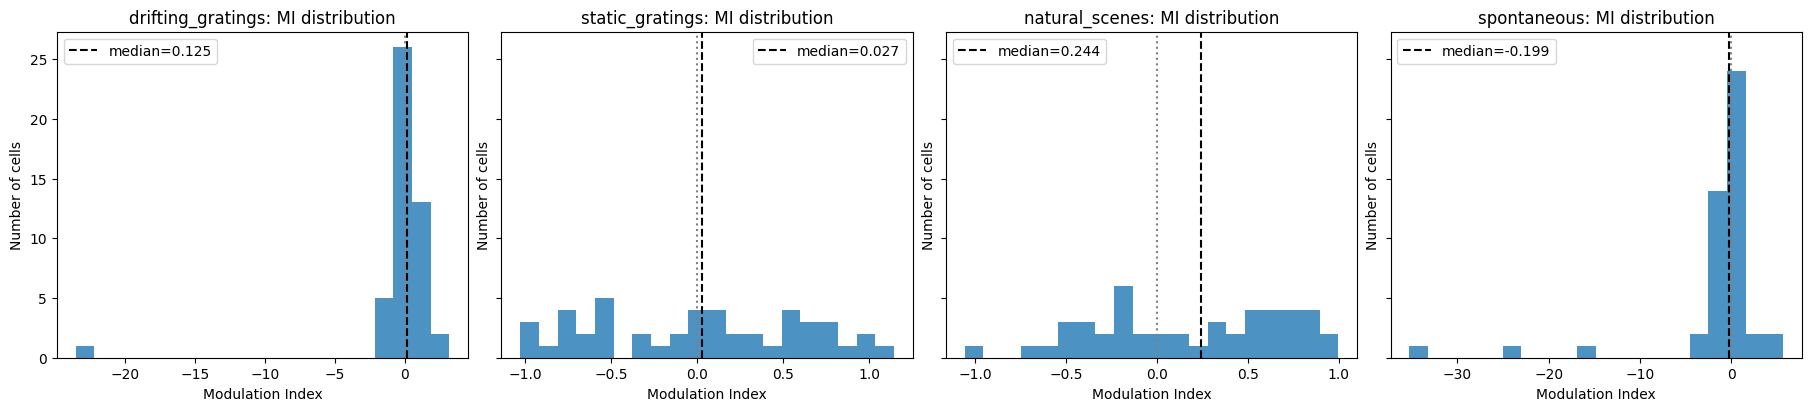

In [5]:
plot_raw_mi_histograms(results)
plt.show()

Some cells show extreme MI values (most visibly for `drifting_gratings` and
`spontaneous`). This occurs when the denominator
$R_{\mathrm{run}} + R_{\mathrm{still}}$ is close to zero: even a tiny response
difference is then divided by a near-zero number, producing an artificially
large MI that reflects numerical instability rather than strong biological
modulation. (Per-cell diagnostics of these extreme values are omitted here;
see the appendix if a detailed breakdown is needed.)

### 1.3 Robust MI distributions

For the main comparisons in this notebook we use a **robust MI**: the same
MI values as above, restricted to cells passing a denominator filter

$$
|R_{\mathrm{run}} + R_{\mathrm{still}}| > 10^{-3}
$$

Raw MI can become unstable when both running and still responses are close
to zero. Therefore, the primary summaries exclude cells with
$|R_{\mathrm{run}}+R_{\mathrm{still}}|\leq10^{-3}$. This is a stability
filter, not a normalization; raw MI is retained as a sensitivity check.

In [6]:
mi_summary = summarize_mi_by_stimulus(results, denom_threshold=DENOM_THRESHOLD)
mi_summary

,stimulus,n_cells,n_robust,n_excluded,median_MI_raw,median_MI_robust,mean_MI_robust,median_delta_R,frac_positive_MI_robust
0,drifting_gratings,47,42,5,0.125199,0.213670,0.225587,0.000783,0.619048
1,static_gratings,47,45,2,0.026739,0.105181,0.036044,0.000226,0.555556
2,natural_scenes,47,47,0,0.244089,0.244089,0.185257,0.001423,0.574468
3,spontaneous,47,35,12,-0.199295,-0.156534,-0.201827,-0.001170,0.457143


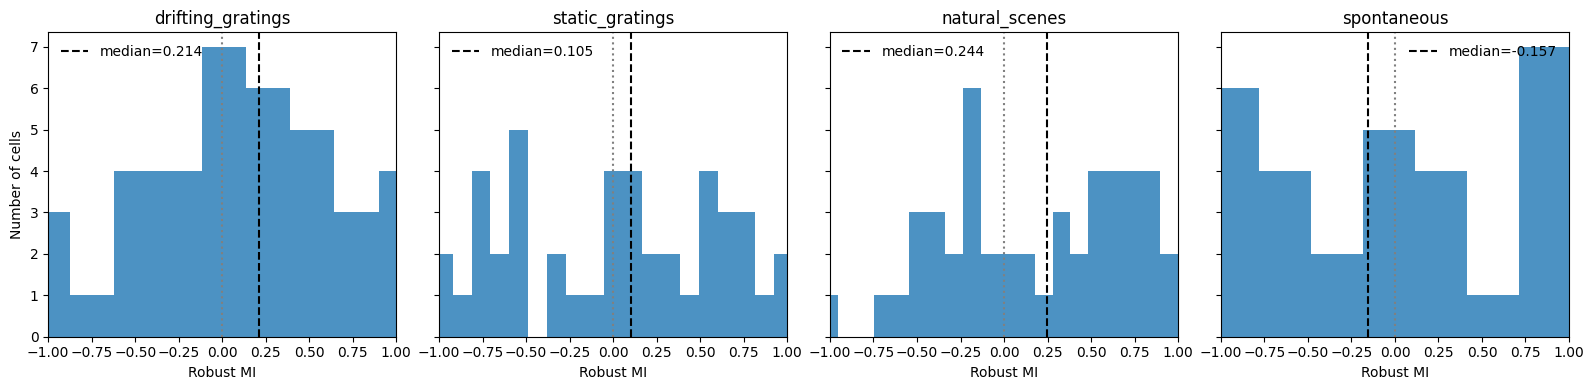

In [7]:
plot_robust_mi_histograms(results, denom_threshold=DENOM_THRESHOLD)
plt.tight_layout()
plt.show()

After robust filtering, `natural_scenes` has the largest median MI
(≈0.244), followed by `drifting_gratings` (≈0.214) and `static_gratings`
(≈0.105) — all positive. `spontaneous` activity has a negative median MI
(≈−0.157). These are **population tendencies**, not universal single-cell
effects: the fraction of cells with positive MI ranges from ≈0.46
(`spontaneous`) to ≈0.62 (`drifting_gratings`), so a substantial minority of
cells in every stimulus class goes against the population trend.

## 2. Population and condition-level modulation

### 2.1 Population running-versus-still responses

Each point below is one neuron: x is its mean response during still trials,
y is its mean response during running trials. The dashed diagonal marks
run = still. Points above the diagonal indicate positive running modulation;
points below indicate negative modulation. This plot is **descriptive** —
it is not itself a significance test.

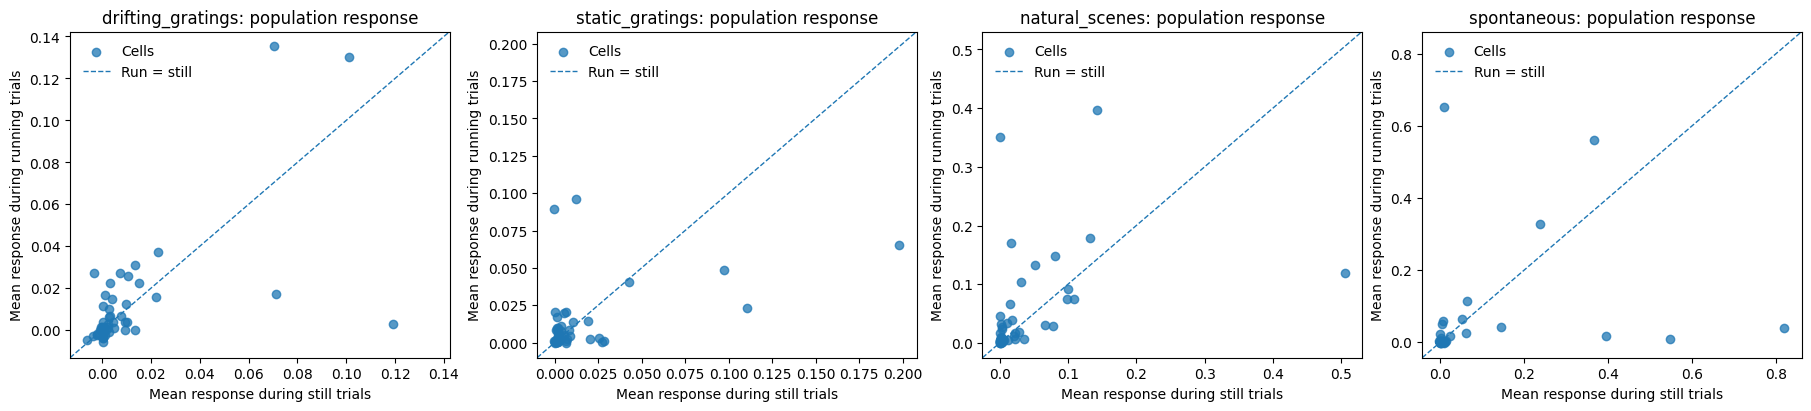

In [8]:
plot_population_response_scatter(results)
plt.show()

Consistent with the MI results, visually evoked responses tend to lie above
the diagonal (positive running modulation), most clearly for
`natural_scenes`. `spontaneous` activity shows a more mixed pattern, with
several cells falling below the diagonal.

### 2.2 Condition-level gain model

For each neuron, we also fit a **condition-level gain model** relating
running and still responses across stimulus conditions (not from one overall
running/still pair):

$$
R_{\mathrm{run},c} = a \cdot R_{\mathrm{still},c} + b
$$

$$
R^2 =
1 -
\frac{\sum_c (R_{\mathrm{run},c} - \widehat{R}_{\mathrm{run},c})^2}
{\sum_c (R_{\mathrm{run},c} - \overline{R}_{\mathrm{run}})^2}
$$

- $a$: fitted multiplicative slope;
- $b$: additive offset;
- $R^2$: fraction of condition-level running-response variance explained by
  the line.

A large slope does not imply a strong gain relationship when $R^2$ is low —
the fit can still be dominated by scatter around the line.

Each stimulus condition contributes one point $(R_{\mathrm{still}},
R_{\mathrm{run}})$ to the fit:

- **Drifting gratings:** orientation × temporal frequency
- **Static gratings:** orientation × spatial frequency × phase
- **Natural scenes:** image identity / frame
- **Spontaneous:** no stimulus identity — gain model is not defined

Below we show a representative `natural_scenes` cell, chosen as one with
enough valid conditions ($\geq 10$) whose fit $R^2$ is close to the
population-median $R^2$ for that stimulus (rather than always the first
eligible cell).

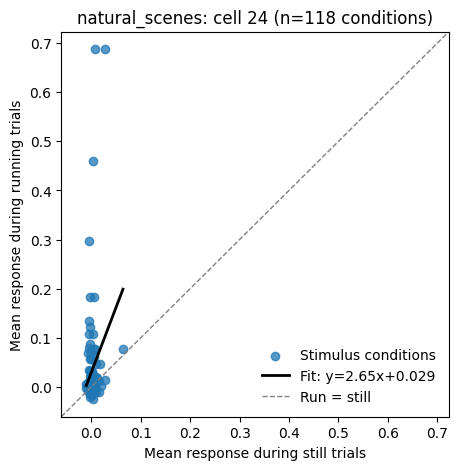

Representative cell: 24
Gain slope a: 2.648
Offset b: 0.0291
Fit R^2: 0.047 (population median R^2 = 0.047)
Number of conditions: 118

Interpretation: this cell was selected because its R^2 is closest to the population median, not because it has the strongest gain. Although the fitted slope is large (a=2.648), the low R^2=0.047 means that the condition-level points are widely scattered and the linear gain model explains only 4.7% of their variance.


In [9]:
stimulus = "natural_scenes"
analysis = results[stimulus]

min_conditions = 10
eligible_cells = np.where(analysis.n_gain_conditions >= min_conditions)[0]

finite_r2 = analysis.gain_r2[np.isfinite(analysis.gain_r2)]
population_median_r2 = np.nanmedian(finite_r2)

r2_eligible = analysis.gain_r2[eligible_cells]
representative_cell = int(
    eligible_cells[np.nanargmin(np.abs(r2_eligible - population_median_r2))]
)

plot_condition_gain_example(analysis, representative_cell)
plt.show()

rep_a = analysis.gain_a[representative_cell]
rep_r2 = analysis.gain_r2[representative_cell]

print("Representative cell:", representative_cell)
print(f"Gain slope a: {rep_a:.3f}")
print(f"Offset b: {analysis.gain_b[representative_cell]:.4f}")
print(
    f"Fit R^2: {rep_r2:.3f} "
    f"(population median R^2 = {population_median_r2:.3f})"
)
print("Number of conditions:", analysis.n_gain_conditions[representative_cell])
print()
print(
    "Interpretation: this cell was selected because its R^2 is closest to "
    "the population median, not because it has the strongest gain. Although "
    f"the fitted slope is large (a={rep_a:.3f}), the low R^2={rep_r2:.3f} "
    "means that the condition-level points are widely scattered and the "
    f"linear gain model explains only {100 * rep_r2:.1f}% of their variance."
)

The interpretation above is generated directly from the fitted values for
the selected cell (not hard-coded), illustrating that a valid condition-level
gain fit does not by itself imply a strong or biologically meaningful
multiplicative relationship.

### 2.3 Population gain summary

Here $a$ is the multiplicative gain, $b$ is the additive offset, and $R^2$
measures how well the simple linear gain model describes the
condition-level responses. A valid fit does not imply a strong or
biologically meaningful one.

In [10]:
gain_summary = summarize_gain_model(results)
gain_summary

,stimulus,n_valid_gain_fits,median_gain_a,median_gain_b,median_gain_r2,median_n_conditions,frac_gain_a_gt_1
0,drifting_gratings,47,0.109210,0.001252,0.107586,6.0,0.085106
1,static_gratings,47,0.273037,0.002341,0.053763,120.0,0.085106
2,natural_scenes,47,0.452296,0.009118,0.047038,118.0,0.234043


Median $R^2$ is low to modest across stimuli (approximately 0.05–0.11),
indicating that the linear gain model captures only a limited part of the
condition-level variability. Natural scenes have the largest fraction of
fitted slopes above one, which is directionally consistent with their larger
median MI. However, $a>1$ alone is not evidence of a strong multiplicative
effect because fit quality is generally limited.

## 3. Gratings versus natural scenes

This is the primary comparison of the project: does locomotion modulate
responses differently for gratings versus natural scenes?

### 3.1 Per-stimulus descriptive summary

The table below (repeated from Section 1.3) reports `drifting_gratings`,
`static_gratings`, `natural_scenes`, and `spontaneous` **separately** —
this is a descriptive summary, not yet a formal comparison.

In [11]:
mi_summary

,stimulus,n_cells,n_robust,n_excluded,median_MI_raw,median_MI_robust,mean_MI_robust,median_delta_R,frac_positive_MI_robust
0,drifting_gratings,47,42,5,0.125199,0.213670,0.225587,0.000783,0.619048
1,static_gratings,47,45,2,0.026739,0.105181,0.036044,0.000226,0.555556
2,natural_scenes,47,47,0,0.244089,0.244089,0.185257,0.001423,0.574468
3,spontaneous,47,35,12,-0.199295,-0.156534,-0.201827,-0.001170,0.457143


### 3.2 Formal paired comparison

Stimuli are never pooled at the trial level. Instead, for each matched
neuron we average its robust drifting- and static-grating MI into a single
grating MI,

$$
MI_{\mathrm{grating}} = \mathrm{mean}(MI_{\mathrm{DG}}, MI_{\mathrm{SG}})
$$

and compare it against natural-scenes MI for the same neurons with a
**paired Wilcoxon signed-rank test**, restricted to cells with a valid
robust MI in all three stimuli.

In [12]:
b6_result, valid_cells, grating_values, natural_values = compare_gratings_vs_natural(
    results, denom_threshold=DENOM_THRESHOLD
)
p_value = float(b6_result["p_value"].iloc[0])
b6_result

,comparison,n_cells,median_grating_MI,median_natural_scene_MI,median_difference_NS_minus_grating,wilcoxon_stat,p_value,frac_NS_greater_than_grating
0,gratings_vs_natural_scenes,41,0.206811,0.290377,0.138758,363.0,0.389209,0.536585


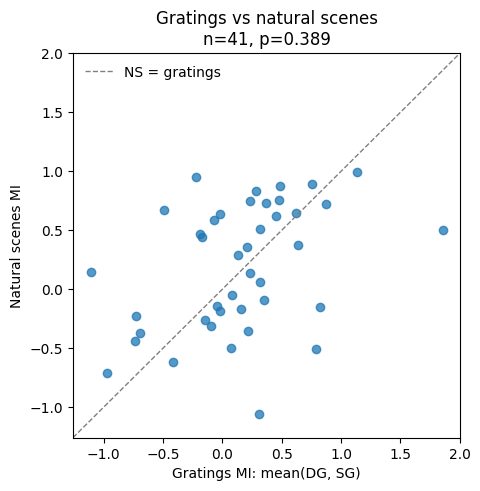

In [13]:
plot_grating_natural_paired_scatter(grating_values, natural_values, p_value=p_value)
plt.show()

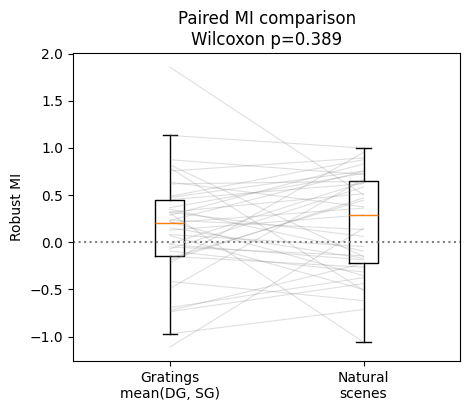

In [14]:
plot_grating_natural_paired_distribution(grating_values, natural_values, p_value=p_value)
plt.show()

Among the n=41 matched cells with valid robust MI in all three stimuli,
natural scenes have a higher median MI (0.290) than the combined grating MI
(0.207); 53.7% of cells show `NS > grating`. However, the paired difference
is **not statistically significant** in this full-cell sample (Wilcoxon
p=0.389). We therefore describe natural scenes as showing a numerically
larger median MI, without claiming a significant grating-versus-natural-scene
difference at the population level.

### 3.3 Comparability caveats

Several factors limit how directly `drifting_gratings`, `static_gratings`,
and `natural_scenes` MI can be compared to each other:

- Drifting-gratings trials (~2 s) are much longer than static-gratings /
  natural-scenes trials (~0.23 s), so the trial-classification window
  captures behavioral state over very different timescales.
- Behavioral-state (running/still) timescales differ from the visual-stimulus
  timescale in each case.
- The number of stimulus conditions and repetitions per condition differs
  substantially across stimuli (see `median_n_conditions` above).
- For `static_gratings` / `natural_scenes`, the short trial window means the
  "all-frames-above/below-threshold" running/still guard is nearly
  equivalent to a simple trial-mean threshold, which is not exactly the case
  for the longer `drifting_gratings` trials.
- Response windows differ in offset and duration across stimuli.

For all these reasons, differences in MI between stimuli cannot be
attributed to visual stimulus type alone.

## 4. Validation against Allen metadata

### 4.1 Robust validation

We validate our MI against Allen's precomputed running-modulation metrics in
`neurons_metadata.csv`, aligned to our matched cells by `cell_specimen_id`:

- `drifting_gratings` → `run_mod_dg`
- `static_gratings` → `run_mod_sg`
- `natural_scenes` → `run_mod_ns`

We use Spearman correlation (MI distributions contain outliers and are not
necessarily normally distributed), on **robust** MI values, consistent with
the main analysis above.

Allen's `run_mod_*` metric and our MI are related but not identical. Allen
evaluates running modulation at the preferred stimulus condition and uses
different speed thresholds and normalization, whereas our MI summarizes
retained running and still trials using a symmetric denominator. Spearman
correlation is therefore used as a directional rank-based validation rather
than a test of numerical equality.

In [15]:
metadata = pd.read_csv("data/neurons_metadata.csv")

validation_df, aligned = validate_mi_against_metadata(
    results,
    metadata,
    data["matched_cell_ids"],
    denom_threshold=DENOM_THRESHOLD,
    robust=True,
)
validation_df

,stimulus,metadata_col,n_cells,spearman_rho,p_value,median_our_MI,median_metadata_run_mod
0,drifting_gratings,run_mod_dg,42,0.132809,4.017772e-01,0.213670,0.329294
1,static_gratings,run_mod_sg,45,0.746377,3.966221e-09,0.105181,0.223448
2,natural_scenes,run_mod_ns,47,0.697155,5.205690e-08,0.244089,0.363075


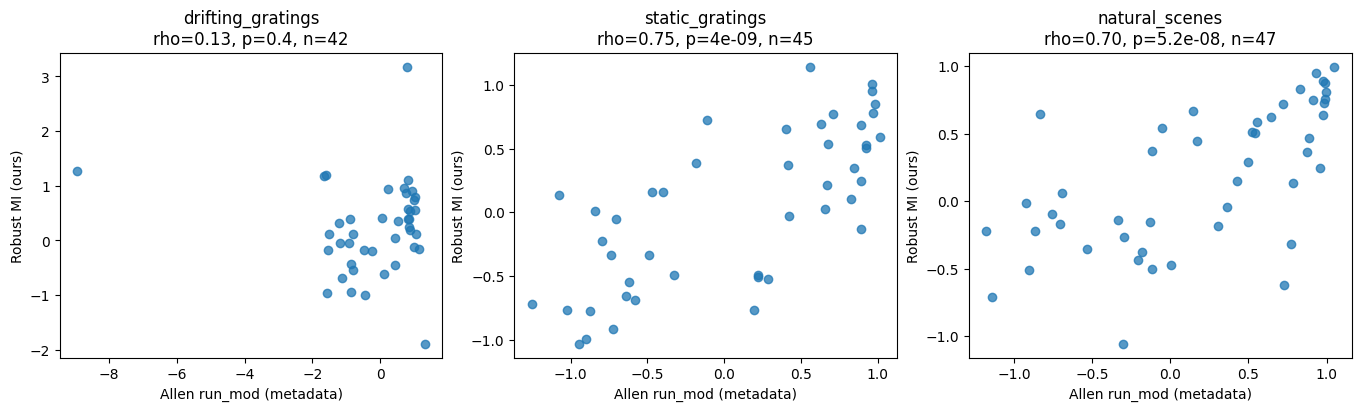

In [16]:
plot_metadata_validation(aligned, validation_df)
plt.show()

`static_gratings` (ρ=0.746, p=4.0e-09) and `natural_scenes` (ρ=0.697,
p=5.2e-08) both show strong, significant positive correlations with the
Allen `run_mod` metrics. `drifting_gratings` shows only a weak,
non-significant correlation (ρ=0.133, p=0.402). For drifting gratings, the
weak non-significant correlation provides limited external validation. This
discrepancy does not by itself identify an implementation error because the
two metrics differ in condition selection, running thresholds, normalization,
and response windows, but the DG MI result should be interpreted cautiously.

Possible contributors include the longer DG trials, within-trial
behavioral-state changes, the small number of still trials, and dilution of
preferred-condition modulation when responses are averaged across all
retained conditions. These are plausible explanations, not confirmed causes.

### 4.2 Raw-versus-robust sensitivity

To check whether the drifting-gratings divergence is caused by the robust
filter itself, we repeat the same validation using **raw** MI (no
denominator-based filtering) and compare side by side.

In [17]:
validation_raw_df, aligned_raw = validate_mi_against_metadata(
    results,
    metadata,
    data["matched_cell_ids"],
    denom_threshold=DENOM_THRESHOLD,
    robust=False,
)

raw_vs_robust = (
    validation_raw_df[["stimulus", "spearman_rho", "p_value"]]
    .rename(columns={"spearman_rho": "rho_raw", "p_value": "p_raw"})
    .merge(
        validation_df[["stimulus", "spearman_rho", "p_value"]]
        .rename(columns={"spearman_rho": "rho_robust", "p_value": "p_robust"}),
        on="stimulus",
    )
)
raw_vs_robust

,stimulus,rho_raw,p_raw,rho_robust,p_robust
0,drifting_gratings,0.161887,2.769716e-01,0.132809,4.017772e-01
1,static_gratings,0.664084,3.599877e-07,0.746377,3.966221e-09
2,natural_scenes,0.697155,5.205690e-08,0.697155,5.205690e-08


The qualitative pattern is unchanged between raw and robust MI: `static_gratings`
and `natural_scenes` remain strongly and significantly correlated with the
Allen metrics, and `drifting_gratings` remains weak and non-significant.
This indicates the drifting-gratings validation divergence is **not** an
artifact of the robust-MI filter.

## 5. Speed-tuned neuron sensitivity analysis

This section will test whether locomotion effects are concentrated in
independently defined speed-tuned neuron subgroups. It is an exploratory
sensitivity analysis; the full matched-cell population remains the primary
analysis.

### 5.1 Cell-group definitions

_To be completed by Analysis A owner: define and align positive, negative,
non-monotonic, significantly tuned, and non-significantly tuned neuron
groups with `data["matched_cell_ids"]`._

### 5.2 MI by speed-tuning group

_To be completed: summarize robust MI and the fraction of positive MI
neurons within each independently defined tuning group._

### 5.3 Gratings versus natural scenes within tuned cells

_To be completed as an exploratory sensitivity analysis. Report sample
size, effect size, and paired statistics without replacing the
full-population B6 result._

### 5.4 Gain model by tuning group

_To be completed: compare `gain_a`, `gain_b`, and `gain_r2` across
independently defined speed-tuning groups._

## 6. Integrated conclusions

### Population modulation
Median robust MI is positive for all visual stimuli and negative during
spontaneous activity, indicating different population-level running
associations in evoked and no-stimulus conditions.

### Gratings versus natural scenes
Natural scenes show the largest descriptive median MI, but the paired
comparison with combined gratings is not statistically significant.
BinaryModulation therefore does not provide strong evidence that
natural-scene modulation is larger than grating modulation.

### Gain structure
Condition-level gain fits are usually computable, but their low-to-modest
$R^2$ values show that a simple linear gain model explains only a limited
fraction of response variability.

### External validation
MI agrees strongly with Allen `run_mod` for static gratings and natural
scenes. Drifting-grating agreement is weak, so the DG result has limited
external validation and should be interpreted cautiously.

### Complementary analyses
BinaryModulation measures average running-versus-still differences, whereas
EncodingModel tests cross-validated predictive information from continuous
speed. Section 5 will provide an exploratory subgroup sensitivity analysis
and will not replace the full-population result.